<img src='https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/tools/frameworks/-/raw/main/img/Standard_banner.png' align='right' width='100%'/>

<a href="../../../Index.ipynb"><< Index</a>
<br>

<font color="#138D75">**Copernicus Marine Training Service**</font> <br>
**Copyright:** 2026 EUMETSAT <br>
**License:** MIT <br>
**Authors:** Vinca Rosmorduc (CLS), Ben Loveday (EUMETSAT/Innoflair UG)

<html>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/applications/ocean-case-studies"><img src="https://img.shields.io/badge/open-EUMETLAB-E67E22.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://user.eumetsat.int/data/themes/marine"><img src="https://img.shields.io/badge/open-USER PORTAL-154360.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://mybinder.org/v2/git/https%3A%2F%2Fgitlab.eumetsat.int%2Feumetlab%2Foceans%2Focean-training%2Fapplications%2Focean-case-studies/HEAD?labpath=Case_studies%2FOcean_dynamics%2FMulti_sensor_eddy_dynamics%2FMulti_sensor_eddy_dynamics_STF.ipynb"><img src="https://mybinder.org/badge_logo.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://jupyterhub.prod.wekeo2.eu/hub/user-redirect/lab/tree/public/wekeo4oceans/ocean-case-studies/Case_studies/Case_studies/Ocean_dynamics/Multi_sensor_eddy_dynamics/Multi_sensor_eddy_dynamics_STF.ipynb"><img src="https://img.shields.io/badge/launch-WEKEO-1a4696.svg"></a></div>
   <div style="float:left"><p>&emsp;</p></div>
   <div style="float:left"><a href="https://code.insula.destine.eu/hub/"><img src="https://img.shields.io/badge/launch-DestinE-f43fd3.svg"></a></div></div>
</html>

<div class="alert alert-block alert-success">
<h3>Ocean case studies</h3></div>

<div class="alert alert-block alert-warning">
    
<b>PREREQUISITES </b>

This notebook has the following prerequisites:
- **<a href="https://eoportal.eumetsat.int/" target="_blank">A EUMETSAT Earth Observation Portal account</a>** to download data from the EUMETSAT Data Store

There are no prerequisite notebooks for this module, but you may wish to look at the following notebooks on using Sentinel-3 data; <br>
- **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-olci" target="_blank">Learn OLCI (EUMETSAT Gitlab)</a>**
- **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-slstr" target="_blank">Learn SLSTR (EUMETSAT Gitlab)</a>**
- **<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/sensors/learn-sral" target="_blank">Learn SRAL (EUMETSAT Gitlab)</a>**

</div>
<hr>

# Monitoring meso- and submesoscale dynamics in the Subtropical Front

### Data used

| Dataset | EUMETSAT collection ID | EUMETSAT collection<br>description | WEkEO dataset ID | WEkEO description |
|:--------------------:|:-----------------------:|:-------------:|:-----------------:|:-----------------:|
| Sentinel-3 SRAL level 2 | EO:EUM:DAT:0415 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:SR_2_WAT___NTC" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:SR_2_WAT___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3ASR_2_WAT___" target="_blank">Description</a> |
| Sentinel-3 OLCI level 2 full resolution (operational) | EO:EUM:DAT:0407 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:OL_2_WFR___NTC" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:OL_2_WFR___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3AOL_2_WFR___" target="_blank">Description</a> |
| Sentinel-3 SLSTR level 2 (operational)| EO:EUM:DAT:0412 | <a href="https://user.eumetsat.int/catalogue/EO:EUM:DAT:SENTINEL-3:SL_2_WST___NTC" target="_blank">Description</a> | EO:EUM:DAT:SENTINEL-3:SL_2_WST___ | <a href="https://www.wekeo.eu/data?view=dataset&dataset=EO%3AEUM%3ADAT%3ASENTINEL-3%3ASL_2_WST___" target="_blank">Description</a> |

FSLE and SWOT products are available through <a href="https://www.aviso.altimetry.fr/en/my-aviso-plus.html" target="_blank">AVISO</a>.

| Dataset | DOI |
|:--------------------:|:-----------------------:|
| FSLE - Maps of Finite Size Lyapunov Exponents and Orientations of the associated eigenvectors | <a href="https://doi.org/10.24400/527896/a01-2022.002" target="_blank">DOI</a> |
|  SWOT Level 3 Ocean Products (Basic)  | <a href="https://doi.org/10.24400/527896/A01-2023.017" target="_blank">DOI</a> |
|  SWOT Level 2 Ocean Products (Unsmoothed) | <a href="https://doi.org/10.24400/527896/a01-2023.016" target="_blank">DOI</a> |

### Learning outcomes

At the end of this notebook you will know how to:
* download, open and plot ocean data from all three Sentinel-3 three sensors (OLCI, SLSTR, SRAL)
* open and plot SWOT data (2-km and 250-m) and altimetry-derived finit-size lyapunov exponents (FSLEs)
* overlay several data on the same figure
* understand how an eddy can appear in all those data, and their respective strengths and drawbacks. 

### Outline

<figure>
  <img src="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/applications/ocean-case-studies/-/raw/main/img/MSE_OC_FSLE.png" width='80%'/>
  <figcaption><a id='figure1'>Figure 1: Multi-sensor view of meoscale and submesoscale process from Sentinel-3 and multisensor FSLE.</figcaption>
</figure>

Mesoscale circulation is a crucial component of ocean circulation. Mesoscale features are ubiquitous in the ocean, and the different satellite sensors bring their own way of observing them. By using several data, one can thus have a more comprehensive view of those structures, including their subfeatures. 

One of the specificities of the Sentinel-3 satellites is that they are carrying three different sensors, all enabling to visualise mesoscale features. This can lead to interesting colocated observations. However, the three sensors do not have the same footprint, and/or not the same centering so a nice acquisition of a mesoscale feature by, say, OLCI (ocean colour) does not mean you will systematically have a SLSTR (SST) one, too, nor a SRAL (SSH) one, independently of the day/night and clouds questions. 

With respect to datasets blending several data sources and filling gaps, L2 satellite imagery provides with higher resolution, thus enabling to observe finer structures. 

<div class="alert alert-info" role="alert">

## <a id='TOCTOP_MSED'></a>Contents

</div>

 1. [Importing dependencies](#IMP_MSED)
 1. [Defining functions](#Defining-functions)
 1. [Setting up our analysis](#section1)
 1. [EUMETSAT Data download](#section2)
 1. [Chlorophyll-A (from S3 OLCI)](#section3)
 1. [SST (from S3 SLSTR)](#section4)
 1. [Nadir altimeter SSHA](#section5)
 1. [Finite-Size Lyapunov Exponent](#section6)
 1. [SWOT SSHA](#section7)
 1. [Multi-sensor plot: overlaying information from several sensors on the same plot](#section8)

<hr>

<div class="alert alert-info" role="alert">

## <a id='IMP_MSED'></a>Importing dependencies
[Back to top](#TOCTOP_MSED)

</div>

In [6]:
import glob                        # a package that helps with file searching
import os                          # a library that allows us access to basic operating system commands
import datetime                    # a library that allows us to work with dates and times
import eumdac                      # a tool that helps us download via the eumetsat/data-store
import getpass                     # a library to help us enter passwords
from pathlib import Path           # a library that helps construct system path objects
import shutil                      # a library that allows us access to basic operating system commands like copy
import zipfile                     # a library that allows us to unzip zip-files.
import numpy as np                 # a library that lets us work with arrays; we import this with a new name "np"
import cartopy.crs as ccrs         # a library that support mapping
import cartopy.feature as cfeature # a library that support mapping
import matplotlib.pyplot as plt    # a library the provides plotting capability
import xarray as xr                # a library that helps us work efficiently with multi-dimensional arrays
import eumartools                  # a EUMETSAT library that support working with Sentinel-3 products
import warnings                    # a library that supports managing warning messages

# turn off warnings
warnings.filterwarnings("ignore")

<div class="alert alert-warning" role="alert">

## <a id='TOCTOP_MSED'></a>Defining functions
[Back to top](#TOCTOP_MSED)

</div>

SLSTR data can be large as the non-time critical data is distributed as full orbit swath. Here we will define a quick function to process that data to improve memory management. We have hidden these cells, by default, but you are welcome to review them if you want to understand how the functions work.

Several information for the plots, including common style applied to all the maps (embellish function), and also the different color maps, minimum, maximum of the color scales are also defined below.

In [7]:
def process_SST_granule(SST_file, region, subsample=1, quality_level=4):
    """
    Quick function to process Level-2 SLSTR granules for memory management. 
    Regionally subsets, applies bias and masks out values lower than the quality level.

    Args:
        SST_file (string)        : the file to process
        region (list)            : the area subset to use when extracting data
        subsample (int)          : the grid subsampling parameter
        quality_level (int)      : the quality level to flag SLSTR data at. Anything lower than this value 
                                   will be discarded
    Returns:
        lon (array)              : the extracted longitude
        lat (array)              : the extracted latitude
        bias_corr_QC_SST (array) : the extracted, bias corrected, quality flagged SST

    """
    K_to_C = 273.15
    
    SST_data = xr.open_dataset(SST_file)

    ext_x, ext_y, ext_mask = eumartools.subset_image(SST_data["lon"][::subsample,::subsample],
                                                     SST_data["lat"][::subsample,::subsample], 
                                                     [region[0], region[1], region[1], region[0]],
                                                     [region[2], region[2], region[3], region[3]],
                                                     mode='global')
    
    ext_x = [i * subsample for i in ext_x] ; ext_y = [i * subsample for i in ext_y]
    minx = np.nanmin(ext_x) ; maxx = np.nanmax(ext_x) ; miny = np.nanmin(ext_y) ; maxy = np.nanmax(ext_y) 

    bias_corr_QC_SST = np.squeeze(
                       np.array(SST_data["sea_surface_temperature"][0,miny:maxy:subsample,minx:maxx:subsample]
                              + SST_data["sses_bias"][0,miny:maxy:subsample,minx:maxx:subsample] - K_to_C))

    flags = np.squeeze(np.array(SST_data["quality_level"][0,miny:maxy:subsample,minx:maxx:subsample]))
    bias_corr_QC_SST[flags < 4] = np.nan

    lon = np.squeeze(np.array(SST_data["lon"][miny:maxy:subsample,minx:maxx:subsample]))
    lat = np.squeeze(np.array(SST_data["lat"][miny:maxy:subsample,minx:maxx:subsample]))
    SST_data.close()

    return lon, lat, bias_corr_QC_SST

In [8]:
def embellish_plot(ax):
    """
    A function to embellish plots
    """
    g1 = ax.gridlines(draw_labels = True, linestyle='--', linewidth=0.5, zorder=1000)
    g1.top_labels = g1.right_labels = False
    g1.xlabel_style = g1.ylabel_style = {'color': '0.5'}

In [9]:
def set_plot_params():
    """
    A function to set colour map parameters for plots
    """
    plot_params = {}
                
    # CHLA plotting parameters
    plot_params["chlacmap"] = 'viridis'
    plot_params["chlamin"] = -2
    plot_params["chlamax"] = 1

    # SST plotting parameters
    plot_params["tempcmap"] = plt.cm.RdYlBu_r
    plot_params["tempmin"] = 16
    plot_params["tempmax"] = 22

    # ALT plotting parameters
    plot_params["sshacmap"] = "PuOr"
    #plot_params["sshacmap"] = "managua" # ~negative of the RdYlBu color map, available for very recent version of Matplotlib
    plot_params["sshamin"] = -0.25
    plot_params["sshamax"] = 0.25

    # FSEL plotting parameters
    plot_params["fslecmap_r"] = "cubehelix_r"
    plot_params["fslecmap"] = "cubehelix"    
    plot_params["fslemin"] = -0.4
    plot_params["fslemax"] = 0

    return plot_params
    
plot_params = set_plot_params()

<div class="alert alert-info" role="alert">

## <a id='section1'></a>1. Setting up our analysis
[Back to top](#TOCTOP)

</div>

As part of this notebook, we will download some Sentinel-3 products from the EUMETSAT Data Store. The switch below, which should be set to `True` by default, will determine if the notebook should download new data, or use what it can already find locally.

*Note: The AVISO SWOT and FSLE products have already been prepared for use by this notebook. For more information on these products, please see the DOIs in the table above.*

In [10]:
download_data = True

Let's now define a download directory (`download_dir`) for products we download, and an output directory (`output_dir`) for our plots and analysis. We will also define the path to our precomputed SWOT and FSLE products (`precomputed_dir`), which are included in this repository.

In [11]:
# Create a download directory for our products
download_dir = os.path.join(os.getcwd(), "products")
os.makedirs(download_dir, exist_ok=True)

# Create an output directory for our plots
output_dir = os.path.join(os.getcwd(), "outputs")
os.makedirs(output_dir, exist_ok=True)

# Locate the directory for our pre-prepared products
precomputed_dir = os.path.join(os.getcwd(), "precomputed")

Lets now the set the parameters for our Sentinel-3 search, defining a region of interest. We'll store all this information in a dictionary called `ROI`.

In [12]:
lon_min = 34 ; lat_min= -43 ; lon_max = 41 ; lat_max = -38 ; 

ROI = {}
ROI["name"] = "SAfrica"
ROI["region"] = [lon_min, lon_max, lat_min, lat_max]
ROI["polygon"] = 'POLYGON(({}))'.format(','.join(["{} {}".format(*coord) for coord in
                                                  [[lon_min, lat_max],
                                                   [lon_max, lat_max],
                                                   [lon_max, lat_min],
                                                   [lon_min, lat_min],
                                                   [lon_min, lat_max]]]))

Now, lets set the time bounds for our search.

In [13]:
ROI["date_start"] = datetime.datetime(2026, 2, 27, 5, 0)
ROI["date_end"] = datetime.datetime(2026, 2, 27, 8, 0)
date_tag = ROI["date_start"].strftime("%Y%m%d")

Finally, lets decide on which products we are interested in. Every product type is stored in a specific collection. You can find more on this in the next section. For now, we are going to provide three collectionIDs for Sentinel-3 OLCI, SLSTR and SRAL, respectively. Finally, lets limit our search only to Sentinel-3A.

In [14]:
ROI["collections"] = ['EO:EUM:DAT:0407', 'EO:EUM:DAT:0412', 'EO:EUM:DAT:0415']
ROI["satellite"] = "Sentinel-3A"

Everything is now set for our Sentinel-3 data request. Lastly, lets define our SWOT and FSLE products, which, for this example, we have pre-downloaded from AVISO.

In [15]:
swot_2kmfile = os.path.join(precomputed_dir,'SWOT_L3_LR_SSH_Basic_046_387_20260227T222055_20260227T231221_v3.0.nc')
swot_250mfile = os.path.join(precomputed_dir,'SWOT_L2_LR_SSH_Unsmoothed_046_387_20260227T222055_20260227T231221_PID0_01_trimmed.nc')
fsle_file = os.path.join(precomputed_dir,'nrt_global_allsat_madt_fsle_'+date_tag+'_20260305.nc')

What we should find, is that we have selected an area south of South Africa, with an eddy, and not too many clouds giving us a good view of both SST and Chlorophyll-A. The overpass is during the day, which is not the best seleciton for SST (night-time data has higer quality), but does provide the optical data we want (e.g. Chlorophyll). We will have both a nadir altimeter track and a SWOT one from a similar time (for SSHA). FSLE data are interpolated using as many altimeters as possible flying at a given time, so we have selected data from the same day as the other data sets.

In the next step, we will fetch our data...

<div class="alert alert-info" role="alert">

## <a id='section2'></a>2. EUMETSAT data download
[Back to top](#TOCTOP)

</div>

<div class="alert alert-block alert-success">

### Accessing the EUMETSAT Data Store

To access Copernicus marine data from the <a href="https://data.eumetsat.int " target="_blank">EUMETSAT Data Store</a>, we will use the EUMETSAT Data Access Client (`eumdac`) python package. If you are working with the recommended Anaconda Python distribution and used the environment file included in this repository (environment.yml) to build this python environment (as detailed in the README), you will already have installed this. If not, you can install eumdac using;

`conda install -c eumetsat eumdac`

You can also find the source code on the <a href="https://gitlab.eumetsat.int/eumetlab/data-services/eumdac " target="_blank">EUMETSAT GitLab</a>. Please visit the EUMETSAT user portal for more information on the <a href="https://user.eumetsat.int/data-access/data-store " target="_blank">EUMETSAT Data Store</a> and <a href="https://user.eumetsat.int/resources/user-guides/eumetsat-data-access-client-eumdac-guide " target="_blank">eumdac</a>.

To download data from the EUMETSDAT Data Store via API, you need to provide credentials. To obtain these you should first register at for an <a href="https://eoportal.eumetsat.int/" target="_blank">EUMETSAT Earth Observation Portal account</a>. Once you have an account, you can retrieve your `<your_consumer_key>` and `<your_consumer_secret>` from the <a href="https://api.eumetsat.int/api-key/ " target="_blank">"EUMETSAT Data Store API"</a> page (*Note: you must click the "Show hidden fields" button at the bottom of the page to see the relevant fields*). If you do not already have a local credentials file, you will be prompted to enter your credentials when you run the cell below. This will create the required local credentials file, so that you only need to run this once.

*Note: your key and secret are permanent, so you should take care to never share them*

</div>

In [11]:
# load credentials
eumdac_credentials_file = Path(Path.home() / '.eumdac' / 'credentials')

if os.path.exists(eumdac_credentials_file):
    consumer_key, consumer_secret = Path(eumdac_credentials_file).read_text().split(',')
else:
    # creating authentication file
    consumer_key = input('Enter your consumer key: ')
    consumer_secret = getpass.getpass('Enter your consumer secret: ')
    try:
        os.makedirs(os.path.dirname(eumdac_credentials_file), exist_ok=True)
        with open(eumdac_credentials_file, "w") as f:
            f.write(f'{consumer_key},{consumer_secret}')
    except:
        pass
        
token = eumdac.AccessToken((consumer_key, consumer_secret))
print(f"This token '{token}' expires {token.expiration}")

This token '59c46a74-4c55-3278-bd6c-e251d797547b' expires 2026-05-21 14:42:23.255123


Now we have a token, we can create an instance of the EUMETSAT Data Store.

In [12]:
datastore = eumdac.DataStore(token)

Data in the Data Store are stored as collections, each with its own ID. If we don't know our collection ID *a priori*, we can find this information via the **<a href="https://data.eumetsat.int/">Data Store GUI</a>** or by asking `eumdac` to tell us about all available SRAL and Poseidon-4 collections as follows:

In [13]:
#list all Sentinel-3 collection IDs 
for collection_id in datastore.collections:
    if ("Sentinel-3" in collection_id.title) and ("Level 2" in collection_id.title):
        if "non-public" in collection_id.abstract: continue
        print(f"Collection ID({collection_id}): {collection_id.title} ")

Collection ID(EO:EUM:DAT:0557): OLCI Level 2 Ocean Colour Reduced Resolution (version BC003) - Sentinel-3 - Reprocessed 
Collection ID(EO:EUM:DAT:0556): OLCI Level 2 Ocean Colour Full Resolution (version BC003) - Sentinel-3 - Reprocessed 
Collection ID(EO:EUM:DAT:0586): SRAL Level 2 Altimetry Global (version BC004) - Sentinel-3 - Reprocessed 
Collection ID(EO:EUM:DAT:0582): SLSTR Level 2 Sea Surface Temperature (SST) (version BC003) - Sentinel-3 - Reprocessed 
Collection ID(EO:EUM:DAT:0834): SRAL Level 2 Altimetry Global (version BC005) - Sentinel-3 - Reprocessed 
Collection ID(EO:EUM:DAT:0407): OLCI Level 2 Ocean Colour Full Resolution - Sentinel-3 
Collection ID(EO:EUM:DAT:0408): OLCI Level 2 Ocean Colour Reduced Resolution - Sentinel-3 
Collection ID(EO:EUM:DAT:0412): SLSTR Level 2 Sea Surface Temperature (SST) - Sentinel-3 
Collection ID(EO:EUM:DAT:0416): SLSTR Level 2 Aerosol Optical Depth - Sentinel-3 
Collection ID(EO:EUM:DAT:0415): SRAL Level 2 Altimetry Global - Sentinel-3 
Co

From the lists above, you can see that we have picked the "OLCI Level 2 Ocean Colour Full Resolution - Sentinel-3" (EO:EUM:DAT:0407), "SLSTR Level 2 Sea Surface Temperature (SST) - Sentinel-3" (EO:EUM:DAT:0412) and "SRAL Level 2 Altimetry Global - Sentinel-3" (EO:EUM:DAT:0415).

Let's now download our Sentinel-3 products. The cell below will loop through each collection, applying our search criteria. It will download every matching products, unzip them from their usual SAFE formats, and clean up.

In [14]:
if download_data:
    # look in all the collections IDs provided in the list in entry
    for collectionID in ROI["collections"]:
        # space/time filter the collection for products
        selected_collection = datastore.get_collection(collectionID)
        print(selected_collection)
        # list the products within the collection matching the start/end dates and the timeliness NTC
        products = selected_collection.search(
            geo=ROI["polygon"],
            dtstart=ROI["date_start"],
            dtend=ROI["date_end"],
            sat=ROI["satellite"])
        for product in products:
            selected_product = datastore.get_product(product_id=product, collection_id=collectionID)
            with selected_product.open() as fsrc, open(os.path.join(download_dir, fsrc.name), mode='wb') as fdst:
                print(f'Downloading {fsrc.name}')
                shutil.copyfileobj(fsrc, fdst)
                print(f'Download of product {fsrc.name} finished.')

            # Unzip the product
            with zipfile.ZipFile(fdst.name, 'r') as zip_ref:
                for file in zip_ref.namelist():
                    if file.startswith(str(selected_product)):
                        zip_ref.extract(file, download_dir)
                print(f'Unzipping of product {selected_product} finished.')
             # Clean up
            os.remove(fdst.name)
            print('------')

EO:EUM:DAT:0407
Download of product S3A_OL_2_WFR____20260227T070408_20260227T070708_20260228T105933_0179_136_291_3600_MAR_O_NT_004.SEN3.zip finished.
Unzipping of product S3A_OL_2_WFR____20260227T070408_20260227T070708_20260228T105933_0179_136_291_3600_MAR_O_NT_004.SEN3 finished.
------
EO:EUM:DAT:0412
Download of product S3A_SL_2_WST____20260227T053851_20260227T071950_20260228T104854_6059_136_290______MAR_O_NT_003.SEN3.zip finished.
Unzipping of product S3A_SL_2_WST____20260227T053851_20260227T071950_20260228T104854_6059_136_290______MAR_O_NT_003.SEN3 finished.
------
EO:EUM:DAT:0415
Download of product S3A_SR_2_WAT____20260227T062921_20260227T071442_20260324T221746_2721_136_291__582_MAR_O_NT_G62.SEN3.zip finished.
Unzipping of product S3A_SR_2_WAT____20260227T062921_20260227T071442_20260324T221746_2721_136_291__582_MAR_O_NT_G62.SEN3 finished.
------


If all went well, you should now have the following products in the download directory (called `products` by default):
* S3A_OL_2_WFR____20260227T070408_20260227T070708_20260228T105933_0179_136_291_3600_MAR_O_NT_004.SEN3
* S3A_SL_2_WST____20260227T053851_20260227T071950_20260228T104854_6059_136_290______MAR_O_NT_003.SEN3
* S3A_SR_2_WAT____20260227T062921_20260227T071442_20260324T221746_2721_136_291__582_MAR_O_NT_G62.SEN3

We now have all the products we need, and can start taking a look at the data.

<div class="alert alert-info" role="alert">

## <a id='section3'></a>3. Chlorophyll-A (from S3 OLCI)
[Back to top](#TOCTOP)

</div>

We will open, mask and plot Chlorophyll-A data from Sentinel-3 (OLCI sensor). The structure of files here is quite different from the other sensors' data below. The OLCI L2 products are including several different netcdf files, with one with the geographical coordinates, one with the different flags (including clouds, ice, lands...), others with the different reflectances, one for suspended sediment... and also two with Chlorophyll-A computed from the previous (two different algorithms). To use the data we thus need to call on several files and combine them together. The files are always named by the same names within a product folder, whatever the date, orbit, etc. of the data tile (contrary to L2 SST and SSH data, which file names include a whole set of information depending on the version, possibly the variant of the data, and also the time of the acquisition and of the processing, and also orbit).

Lets identify our ocean colour product...

In [16]:
OLCI_SAFE_product = glob.glob(os.path.join(download_dir, '*WFR*'))[0]

In [17]:
# the geo_coordinates.nc file includes all the geo location information
geo_file = os.path.join(OLCI_SAFE_product, 'geo_coordinates.nc')
geo_fid = xr.open_dataset(geo_file)
lon = geo_fid.longitude.data
lat = geo_fid.latitude.data
geo_fid.close()

# chl_nn.nc provide with the ChlA, computed using a Neural Network algorithm
chla = xr.open_dataset(os.path.join(OLCI_SAFE_product, 'chl_nn.nc'))

We will also use the flags, provided in a separate file (wqsf.nc), to remove clouds, lands, sun glints, and spurious data. We use a dedicated module "eumartools".

In [18]:
flag_file = os.path.join(OLCI_SAFE_product, 'wqsf.nc')
flag_vars = xr.open_dataset(flag_file)
chla["WQSF"] = flag_vars["WQSF"]

# reading masks: all recommended flags NN ; we use a dedicated EUMETSAT tool here
NN_mask = eumartools.flag_mask(flag_file, 'WQSF', ['LAND', 'CLOUD', 'CLOUD_AMBIGUOUS', 'CLOUD_MARGIN', 
                                                    'INVALID', 'COSMETIC', 'SATURATED', 'SUSPECT',
                                                    'HISOLZEN', 'HIGHGLINT', 'SNOW_ICE', 'OCNN_FAIL'])
NN_mask = NN_mask.astype(float)
NN_mask[NN_mask != 0.0] = np.nan
NN_mask[NN_mask == 0.0]= 1.0
flag_vars.close()

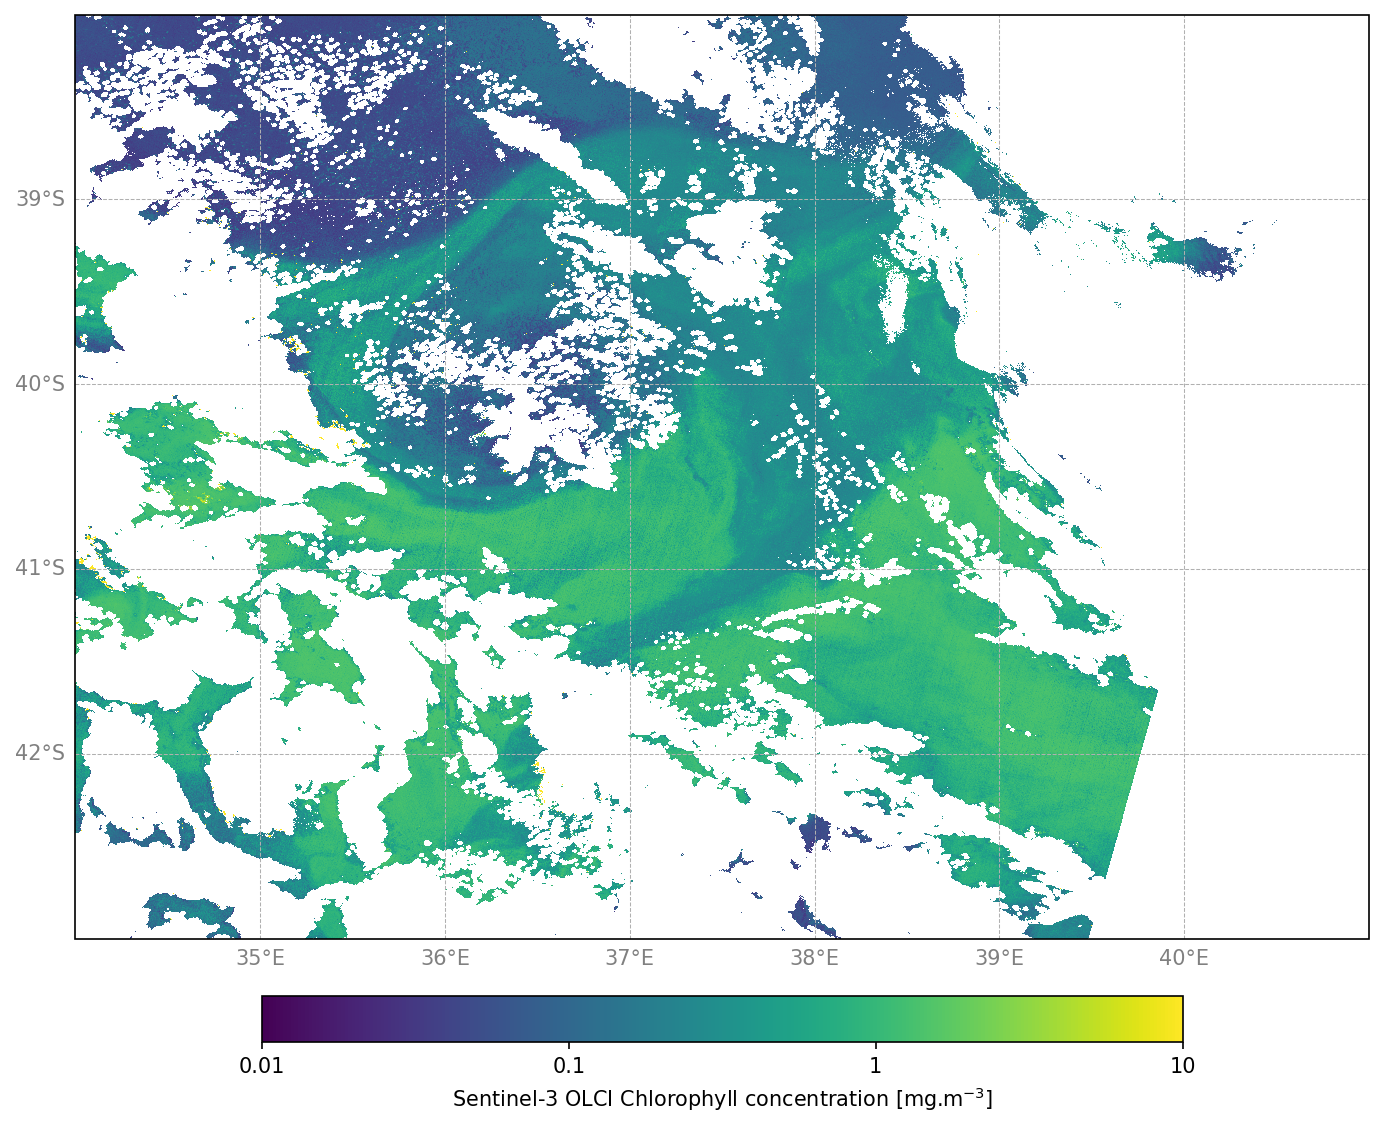

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(ROI["region"], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=0)

# plot the ChlA field
p1 = ax.pcolormesh(lon, lat, chla['CHL_NN']*NN_mask, transform=ccrs.PlateCarree(), cmap=plot_params["chlacmap"],
                   vmin=plot_params["chlamin"], vmax=plot_params["chlamax"], zorder=1)

# add some map embellishments
embellish_plot(ax)

cbar = fig.colorbar(p1, ax=ax, location='bottom', pad=0.05, shrink=0.66)
ticks = list(range(plot_params["chlamin"], plot_params["chlamax"] + 1))
cbar.set_ticks(ticks)
cbar.set_ticklabels([10**tick for tick in ticks])
cbar.set_label('Sentinel-3 OLCI Chlorophyll concentration [mg.m$^{-3}$]')

plt.savefig(os.path.join(output_dir, 'OLCI_CHLNN_'+date_tag+'_'+ROI["name"]+'.png'), bbox_inches='tight', transparent=True)
plt.show()

OLCI is an optical sensor (i.e., functionning at visible wavelengths), collecting sun light reflected by the ocean. It is thus dependent on the local hour (local daytime only), but also to clouds. The Chlophyll-A L2 OLCI data is natively available at 300 m.

<div class="alert alert-info" role="alert">

## <a id='section4'></a>4. SST (from S3 SLSTR)
[Back to top](#TOCTOP)

</div>

We are plotting a SST file from S3. Those data, as the ChlA ones, are in swathes; the file retrieved (only one file in the product folder) includes a whole orbit, though, so much more than needed here. We have defined, above, a function "process_SST_granule" to subset the area, to potentially subsample and to select only the valid data. 

The function use a dedicated module "eumartools" which deals here with the geographical subsetting of the data. The function also convert Kelvin in degrees Celsius, apply quality flags and bias.

In [20]:
SLSTR_SAFE_product = glob.glob(os.path.join(download_dir, "*WST*", "*.nc"))[0]

# sub-sampling for SLSTR pre-processing: subsample default = 1 implies no subsampling 
lon_sst, lat_sst, sst = process_SST_granule(SLSTR_SAFE_product, ROI["region"], subsample=1)

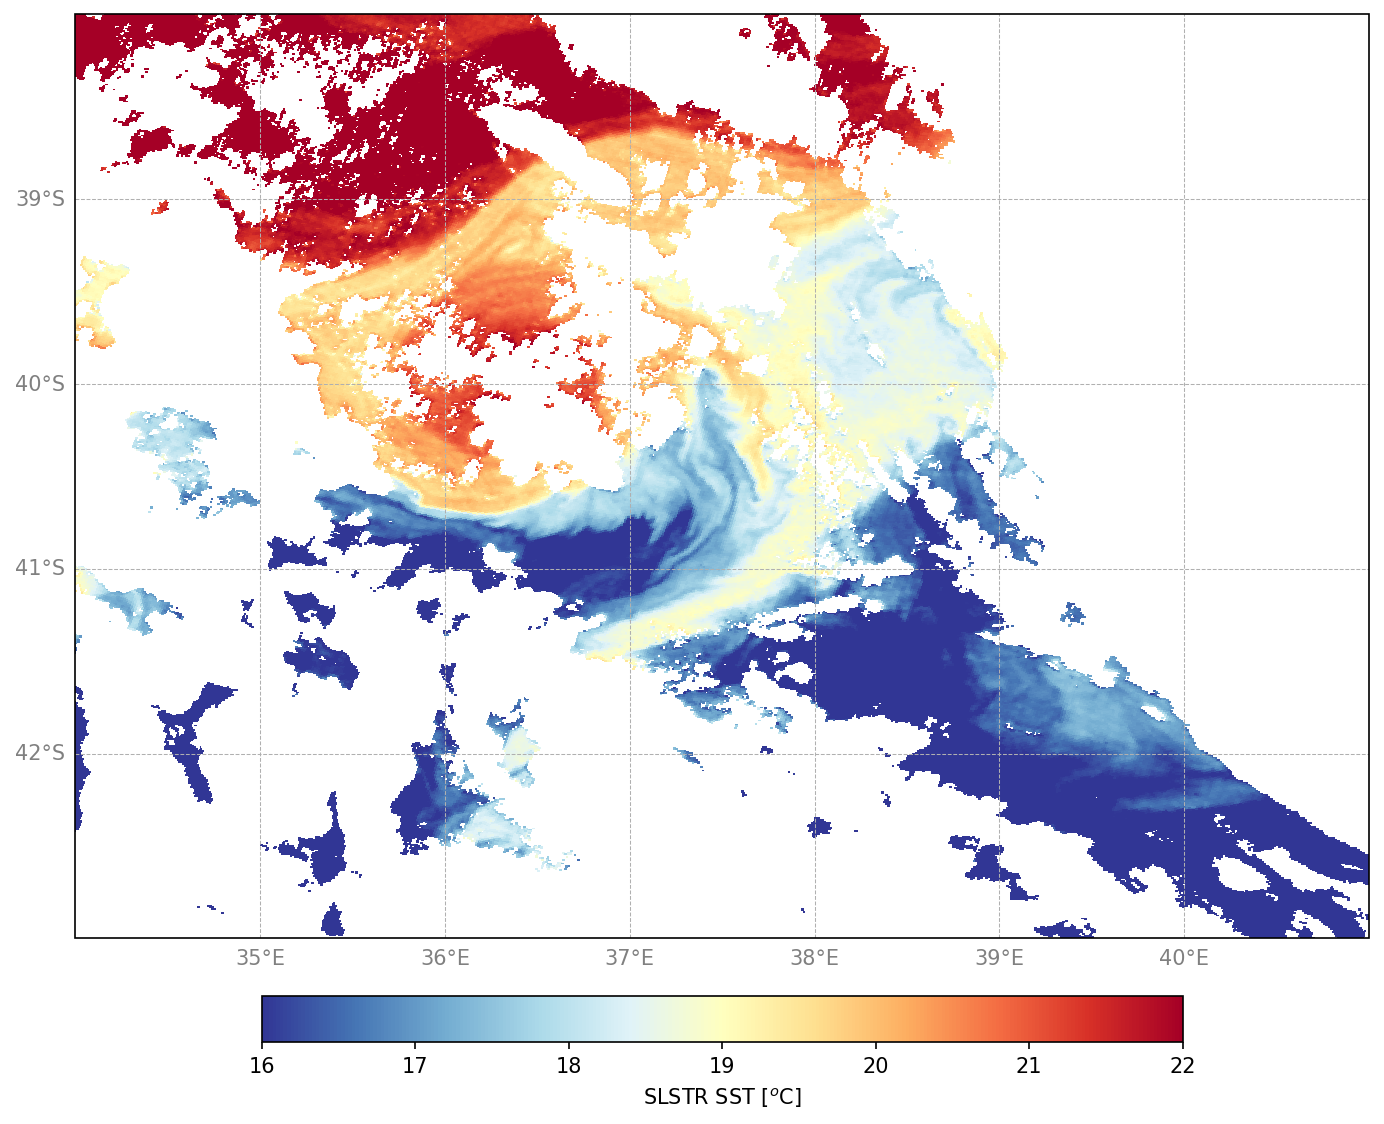

In [21]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(ROI["region"], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=0)

# plot the SST field
sst_plot = ax.pcolormesh(lon_sst, lat_sst, sst, cmap=plot_params["tempcmap"],
                         vmin=plot_params["tempmin"], vmax=plot_params["tempmax"], zorder=1)

# add some map embellishments
embellish_plot(ax)

# add the colour bar
cbar = fig.colorbar(sst_plot, ax=ax, location='bottom', pad=0.05, shrink=0.66)
cbar.ax.tick_params() 
cbar.set_label('SLSTR SST [$^{o}$C]')
plt.savefig(os.path.join(output_dir, 'SLSTR_'+date_tag+'_'+ROI["name"]+'.png'), bbox_inches='tight', transparent=True)
plt.show()

Sea surface temperature data are computed from the thermal emission of the surface. It is not dependent on local day time, but processing is different during day than during night. 

<div class="alert alert-info" role="alert">

## <a id='section5'></a>5. Nadir altimeter SSHA (from S3 SRAL)
[Back to top](#TOCTOP)

</div>

We will plot the SSHA from a nadir satellite (here Sentinel-3A) over the area on the same day. As nadir altimeters only measure just beneath them, the data is a line of measurements (the "track"). If measuring over an eddy, you can see the profile of it in sea surface height anomalies along the track. Moreover, with several satellites, and data from different days, you can fill in the gaps and produces data grids ("l4" data, available through Copernicus Marine Service). As altimetry is an active sensor, functionning in microwave wavelengths, it is not sensitive to either clouds or local time. 

In [22]:
# glob.glob deals with the wildcard ("*"). It provides a list, here of only one element - there are three netcdf in the product folder, 
# but we choose to use only one of them, the "Reduced" file ('RED' in the file name), including the main variables we'll to use in this case
SRAL_SAFE_product = glob.glob(os.path.join(download_dir, "*WAT*", "*_RED_*.nc"))[0]

nadir_data = xr.open_dataset(SRAL_SAFE_product)
latnadir = nadir_data['lat_01']
lonnadir = nadir_data['lon_01']
sshanadir = nadir_data['ssha_01_ku']
nadir_data.close()

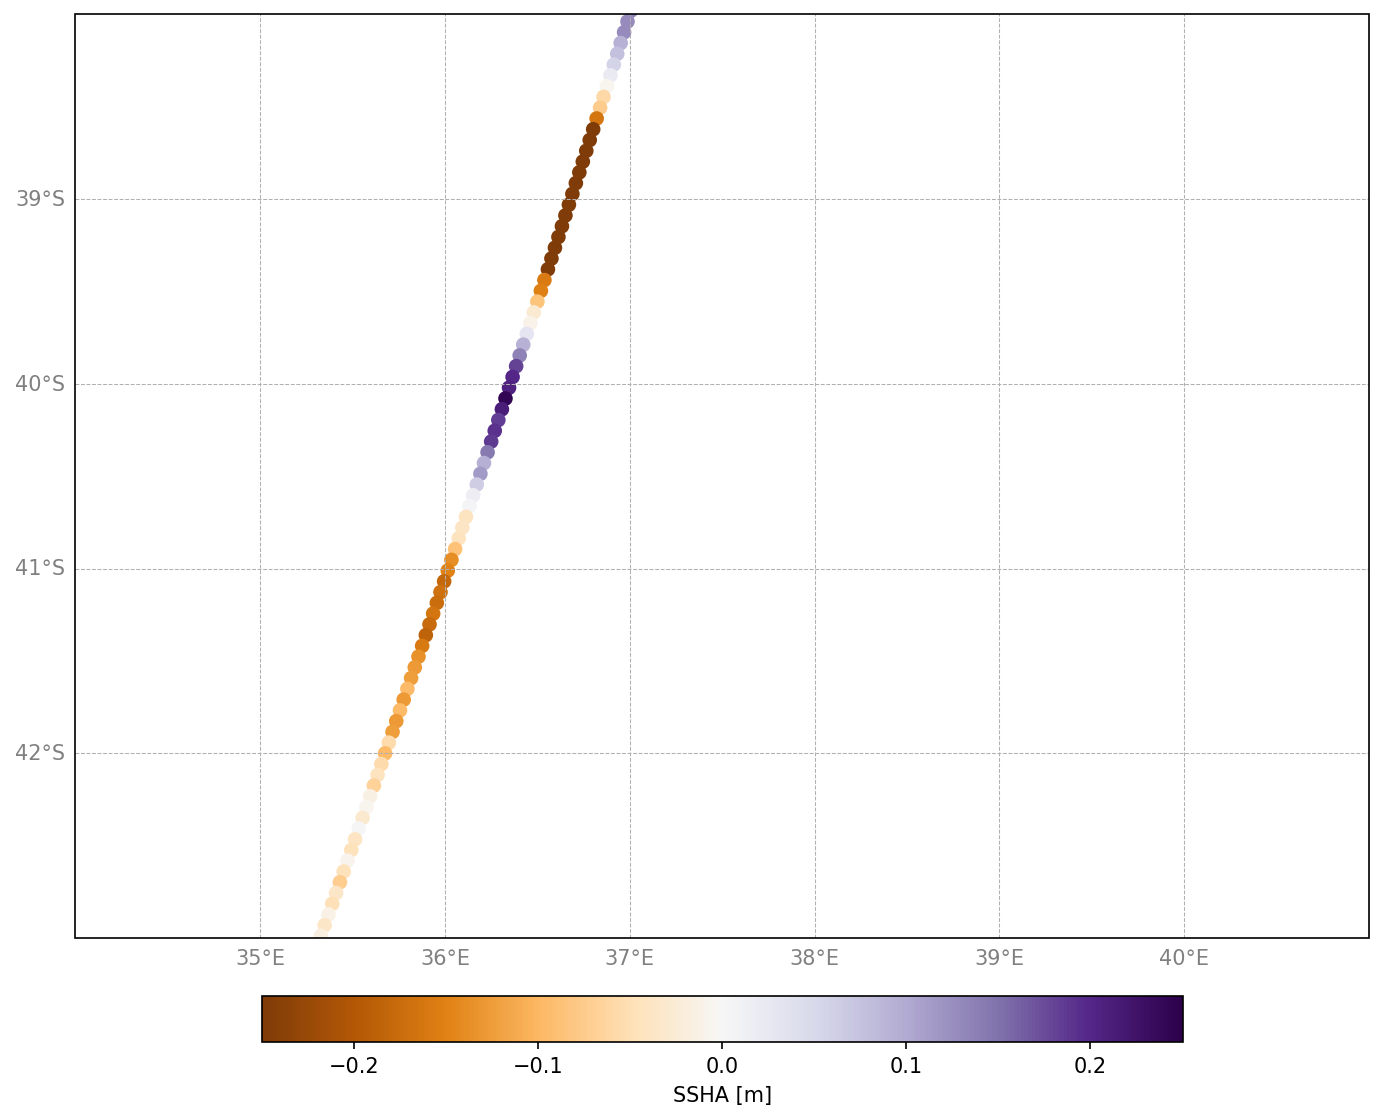

In [23]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(ROI["region"], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=0)

# plot the SSHA field
track = ax.scatter(lonnadir, latnadir, c=sshanadir, cmap=plot_params["sshacmap"],
                   vmin=plot_params["sshamin"], vmax=plot_params["sshamax"], marker='o', edgecolors=None, linewidth=1,
                   transform=ccrs.PlateCarree(central_longitude=0), zorder=1)

# add some map embellishments
embellish_plot(ax)

cbar = fig.colorbar(track, ax=ax, location='bottom', pad=0.05, shrink=0.66)
cbar.set_label('SSHA [m]')

plt.savefig(os.path.join(output_dir, 'nadir_'+date_tag+'_'+ROI["name"]+'.png'), bbox_inches='tight', transparent=True)
plt.show()

<div class="alert alert-info" role="alert">

## <a id='section6'></a>6. Wide-swath SSHA from SWOT
[Back to top](#TOCTOP)

</div>

SWOT is using a new design in altimetry, using interferometry to measure in two dimensions, over two swathes of about 50 km (with a gap in the middle, partly filled by a more classical nadir altimeter).
Over ocean basic data are in a 2-km resolution; we are using the "Level-3" (precomputed data, including also the nadir measurements, with SSHA corrected for the cross-over height correction)

In [24]:
swot_data = xr.open_dataset(os.path.join(precomputed_dir, swot_2kmfile))
latswot = swot_data['latitude']
lonswot = swot_data['longitude']
dataswot = swot_data['ssha_unfiltered']
swot_data.close()

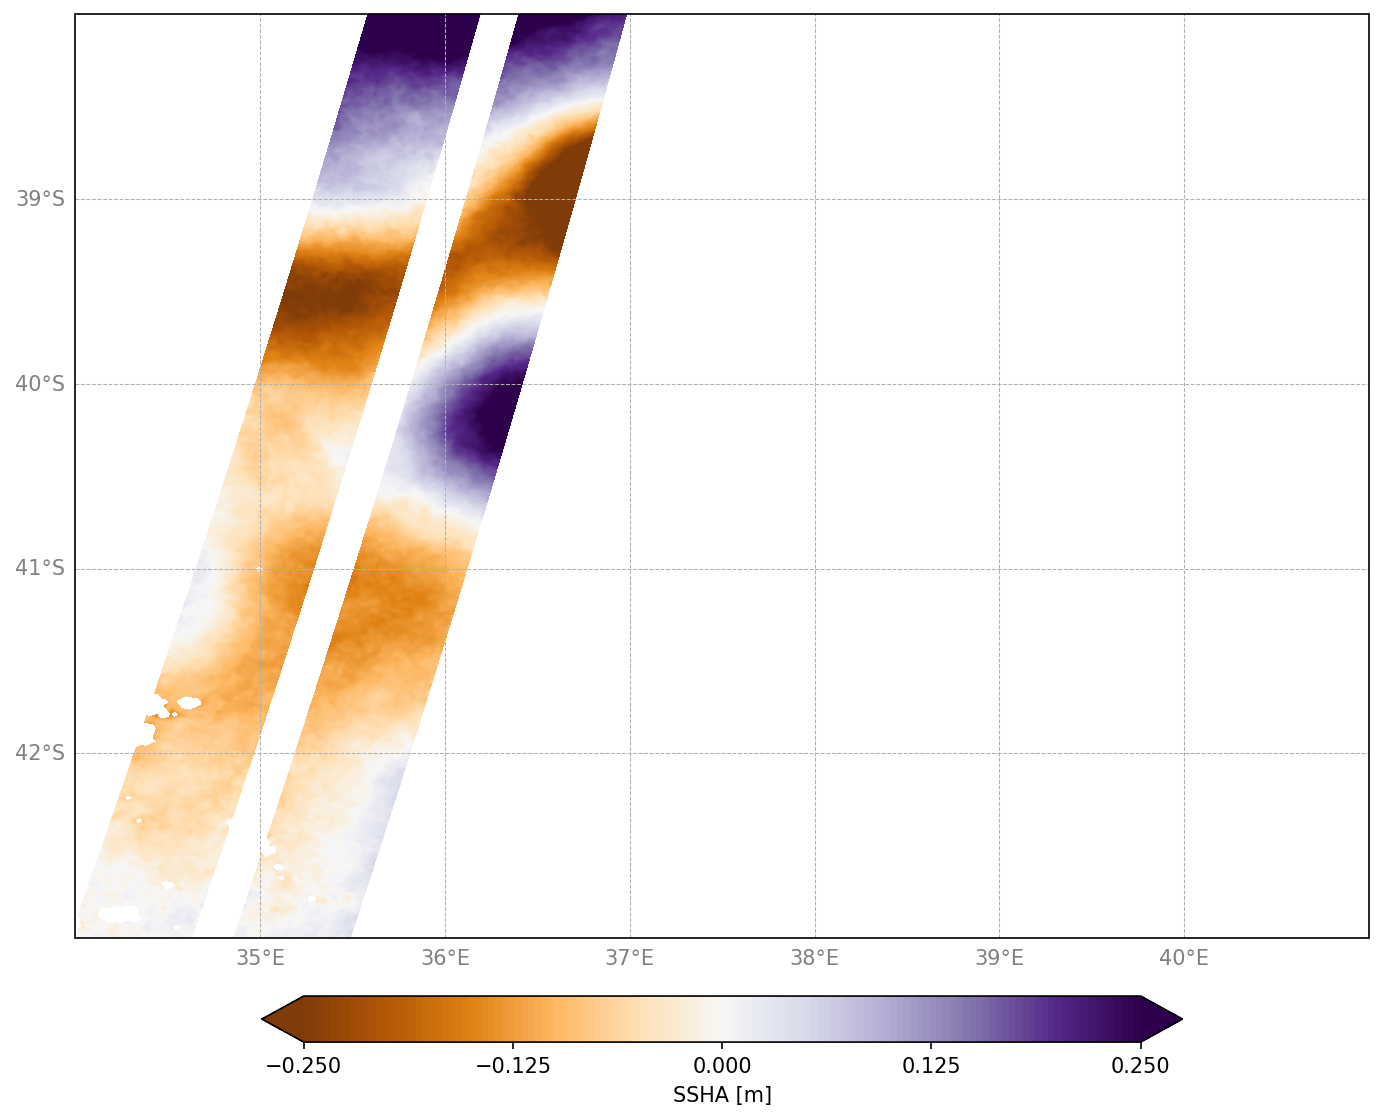

In [25]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(ROI["region"], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=0)

# plot the SSHA field ; 
swathes = ax.contourf(lonswot, latswot, dataswot, levels=np.linspace(plot_params["sshamin"], plot_params["sshamax"],128),
                      cmap=plot_params["sshacmap"], vmin=plot_params["sshamin"], vmax=plot_params["sshamax"], alpha=1,
                      transform=ccrs.PlateCarree(), zorder=1, extend='both')

# add some map embellishments
embellish_plot(ax)

# add a colour bar
levels_cont = np.linspace(plot_params["sshamin"], plot_params["sshamax"],5)
cbar = fig.colorbar(swathes, ax=ax, location='bottom', pad=0.05, shrink=0.66, ticks=levels_cont)
cbar.ax.tick_params()
cbar.set_label('SSHA [m]')

plt.savefig(os.path.join(output_dir, 'Swot2km_'+date_tag+'_'+ROI["name"]+'.png'), bbox_inches='tight', transparent=True)
plt.show()
plt.close()

We now will have a short view on the highest SWOT resolution over ocean, 250 m (note that it is even higher over land waters and some coastal areas).

If you just need bacscatter coefficient (sigma0), SSHA, longitude, latitude..., we would recommend using the L3 "unsmoothed" data whenever available (not yet for the date used here). 
The L2 "unsmoothed" files are organised in two groups, one for each swath (left and right). We restricted as much as possible the data (removing all the variables we will not use for this notebook, restricting the area...) in the precomputed file provided, so as not to overload the notebook.

For ready-to-use codes and dedicated tools, proper editing etc., see https://swot-community.github.io/SWOT-galleries/ 

In [26]:
swot_left = xr.open_dataset(swot_250mfile, group='left', chunks={})
swot_right = xr.open_dataset(swot_250mfile, group='right', chunks={})

extr_swot_left = swot_left.where( ((swot_left.longitude >= lon_min) & (swot_left.longitude < lon_max) \
                      & (swot_left.latitude >= lat_min) & (swot_left.latitude < lat_max)).compute(), drop=True)
swot_left.close()
lat_hrl_swot = extr_swot_left['latitude']
lon_hrl_swot = extr_swot_left['longitude']
sig_hrl_swot = extr_swot_left['sig0_karin_2']
extr_swot_left.close()

extr_swot_right = swot_right.where( ((swot_right.longitude >= lon_min) & (swot_right.longitude < lon_max) \
                      & (swot_right.latitude >= lat_min) & (swot_right.latitude < lat_max)).compute(), drop=True)
lat_hrr_swot = extr_swot_right['latitude']
lon_hrr_swot = extr_swot_right['longitude']
sig_hrr_swot = extr_swot_right['sig0_karin_2']
extr_swot_right.close()

We will plot on a smaller area than above, adding the 2km-SSHA (colored) contours for reference.

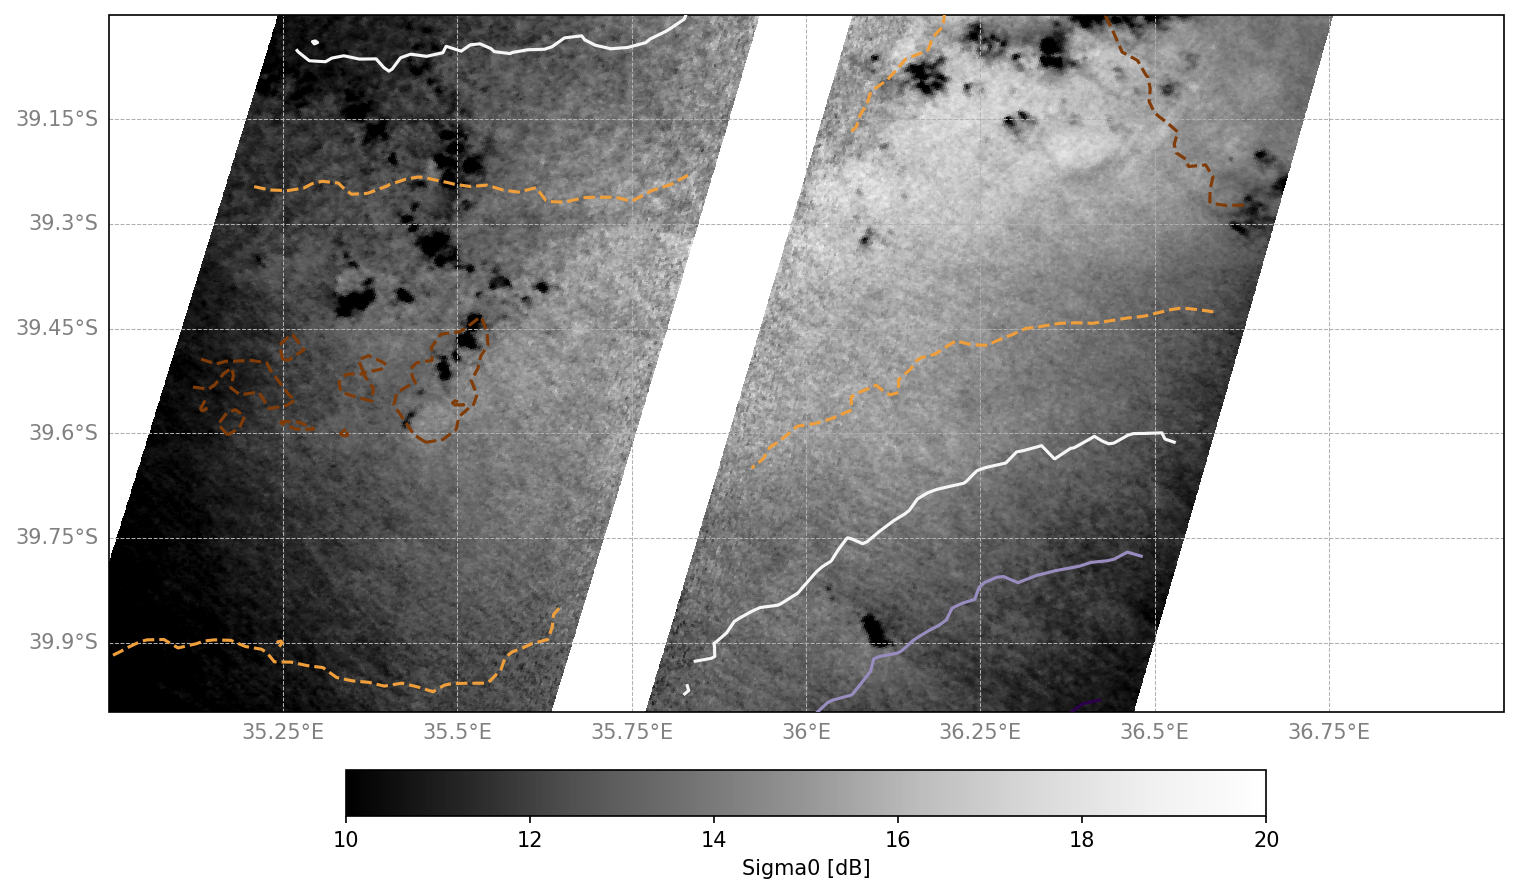

In [27]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([35, 37, -40, -39], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=0)

sig0_l = ax.pcolormesh(lon_hrl_swot, lat_hrl_swot, sig_hrl_swot, cmap='Greys_r', vmin=10, vmax=20, transform=ccrs.PlateCarree())
sig0_r = ax.pcolormesh(lon_hrr_swot, lat_hrr_swot, sig_hrr_swot, cmap='Greys_r', vmin=10, vmax=20, transform=ccrs.PlateCarree())
swathcont = ax.contour(lonswot, latswot, dataswot, cmap=plot_params["sshacmap"], levels=levels_cont, linestyles=np.where(levels_cont >= 0, "-", "--"), linewidth=0.1, alpha=1, transform=ccrs.PlateCarree(), zorder=5, extend='both')

# add some map embellishments
embellish_plot(ax)

# add a colour bar
cbar = fig.colorbar(sig0_r, ax=ax, location='bottom', pad=0.05, shrink=0.66)
cbar.ax.tick_params()
cbar.set_label('Sigma0 [dB]')

plt.savefig(os.path.join(output_dir, 'Swot250m_'+date_tag+'_'+ROI["name"]+'.png'), bbox_inches='tight', transparent=True)
plt.show()

Some very small features are visible in the sigma0 (linked to the roughness of the surface). They may (or not) be linked to ocean circulation submesoscale features, depending on the area and situation.

<div class="alert alert-info" role="alert">

## <a id='section7'></a>7. Finite-Size Lyapunov Exponent
[Back to top](#TOCTOP)

</div>

Lyapunov exponents are an quantity which reflects the time it would take for two adjacent water particles (or e.g. drifting buoys) to separate. Here they are expressed in day-1, so 0 means it would take an infinite time for two particles to separate (i.e., close to zero we are in an area of convergence), while -0.4 means it would take about 2.5 days. The computation of those exponent is using (long) time series either before or after the represented date (forward or backward processing). 

In [28]:
ds_fsle = xr.open_dataset(fsle_file)

# extraction of only the area of interest. Note that the longitudes are expressed 0-360, so you may have to transform lon_min and lon_max if negative.
extr_fsle = ds_fsle.sel(lon=slice(lon_min,lon_max), lat=slice(lat_min,lat_max))
ds_fsle.close()

fsle = extr_fsle['fsle_max'][0]
lon_fsle = extr_fsle['lon']
lat_fsle = extr_fsle['lat']
extr_fsle.close()

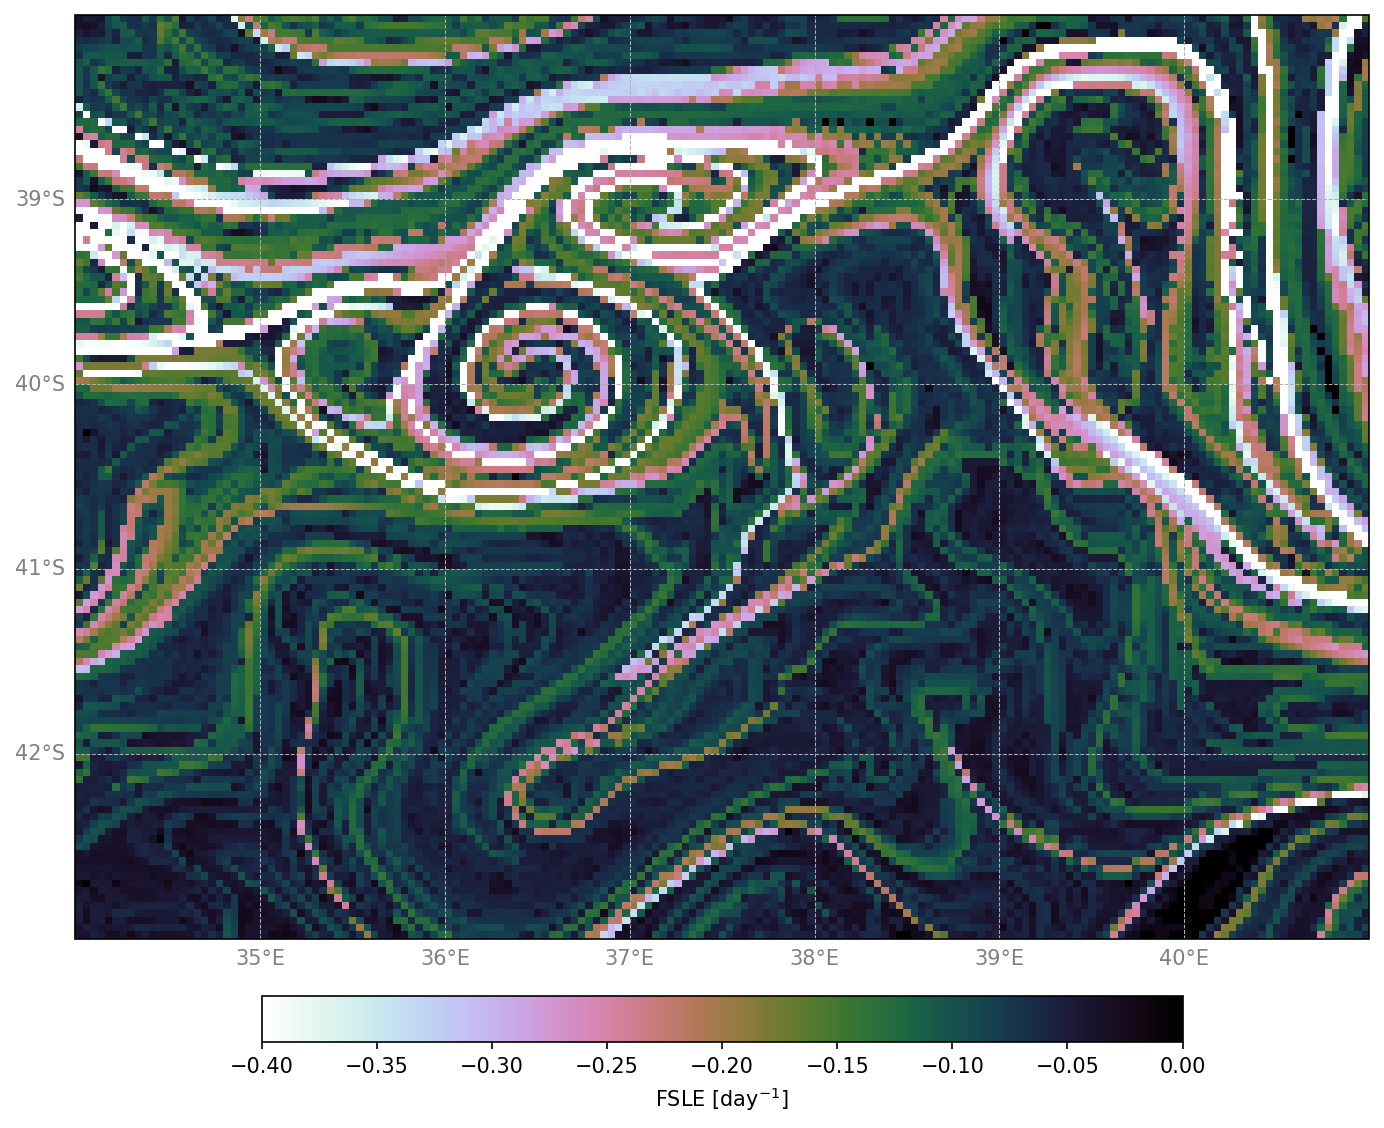

In [29]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(ROI["region"], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=0)

# plot the FSLE field
fslemap = ax.pcolormesh(lon_fsle, lat_fsle, fsle, vmin=plot_params["fslemin"], vmax=plot_params["fslemax"], cmap=plot_params["fslecmap_r"], alpha=1, zorder=1)

# add some map embellishments
embellish_plot(ax)

# add a colour bar
listeticks=np.linspace(plot_params["fslemin"], plot_params["fslemax"], 9)
cbar = fig.colorbar(fslemap, ax=ax, location='bottom', pad=0.05, ticks=listeticks, shrink=0.66)
cbar.ax.tick_params() 
cbar.set_label('FSLE [day$^{-1}$]')

plt.savefig(os.path.join(output_dir, 'fsle'+date_tag+'_'+ROI["name"]+'.png'), bbox_inches='tight', transparent=True)
plt.show()

This is a plot made from a computation of a large number of altimetry measurements (L4 data). It is showing several spiral-shaped structures of divergent filaments. Now, we will try to see if we are seeing the same eddy through all those different eyes... or not. 

<div class="alert alert-info" role="alert">

## <a id='section8'></a>8. Multi-sensor plot: overlaying information from several sensors on a plot
[Back to top](#TOCTOP)

</div>

Now, to see several data together, we will overlay a number of the data seen above. We will have to play on transparency (i.e. "alpha") so as to be able to interpret more than the top one, and/ot to use contours.

In [30]:
# compute an alpha depending on the value of the FLSE variable, to show the "divergent" filaments more than the convergent areas; 
# alpha code the transparency of a color/figure, from 0 (full transparency) to 1 (solid color, no transparency).
# Since the FSLE values can be NaN, and are always negative (at the highest 0), which an alpha can't be
# and thus also in inverse order than what we wish to put forward this leads to a convoluted definition.
# After testing, we chose to divide the computed alpha by 4, to only have the strongest divergent filaments appear

# transform all NaN values to zero (alpha will be zero for those, = full transparency)
# xarray dataset to numpy array
fsle_np = fsle.values.astype(float)
# define valid values 
valid = np.isfinite(fsle_np)
#create a numpy array of the same size and shape than the fsle one, filled with zeros
alphas = np.zeros_like(fsle_np)
# compute the alphas from abs(fsle)
alphas[valid] = np.abs(fsle_np[valid]) / (np.abs(plot_params["fslemin"])*4)
# remove values which may be higher than 1
alphas = np.clip(alphas, 0, 1)

levels = np.linspace(plot_params["sshamin"], plot_params["sshamax"], 128)
levels_cont = np.linspace(plot_params["sshamin"], plot_params["sshamax"], 5)

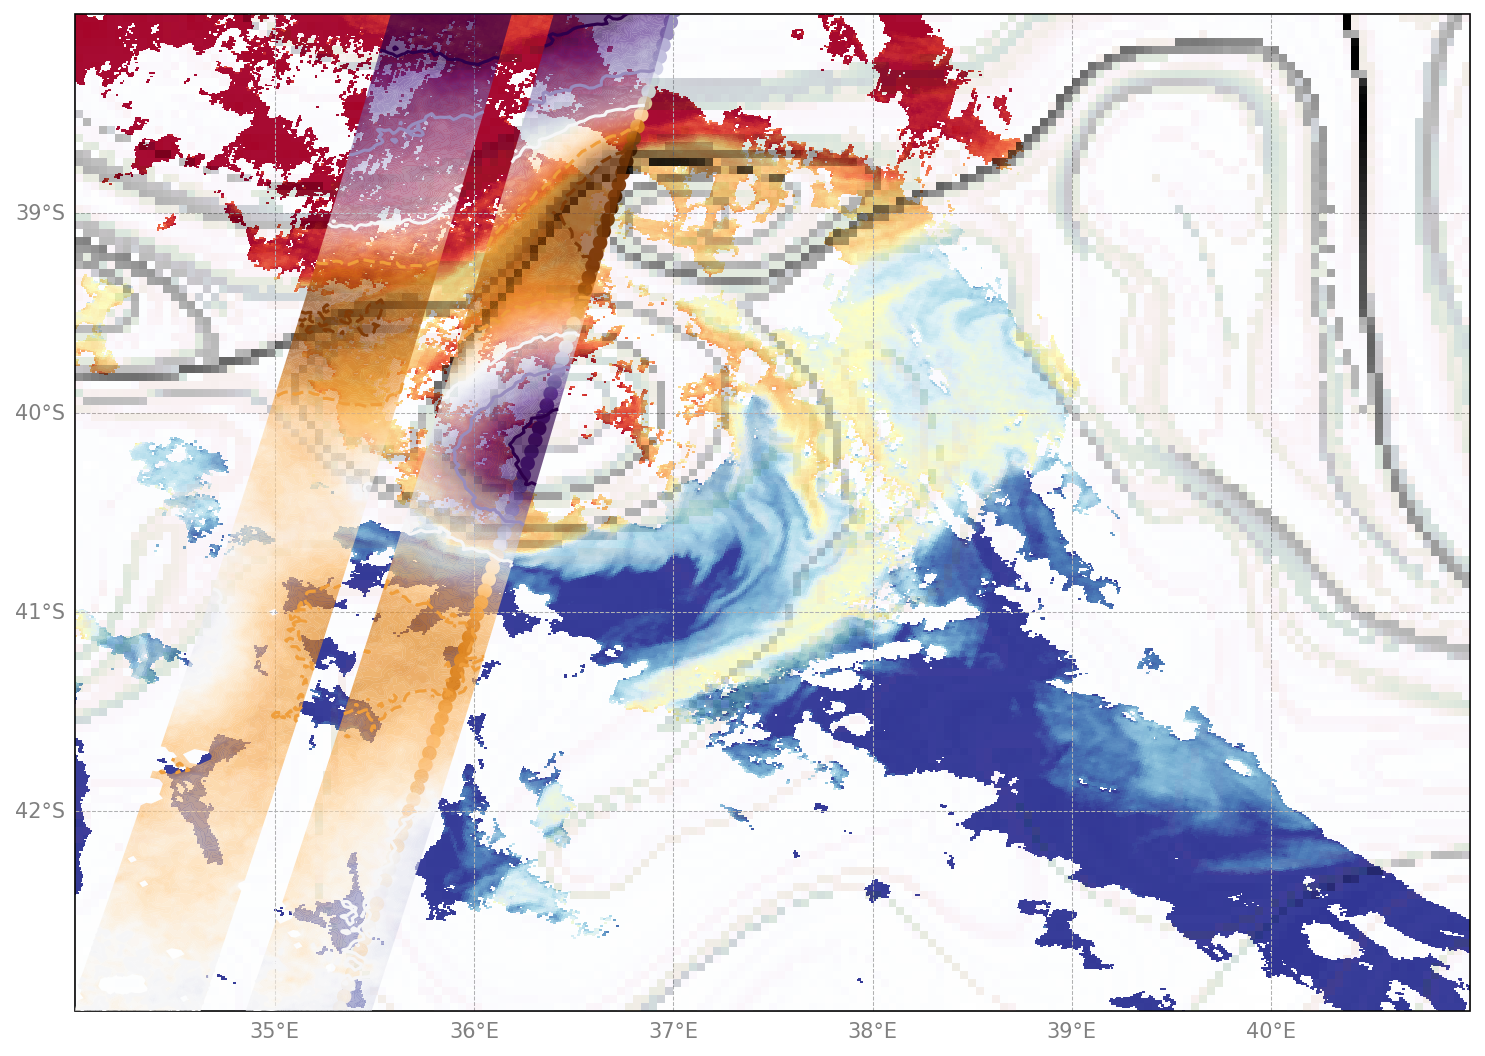

In [31]:
# setup figure
fig, ax = plt.subplots(1, 1, figsize=(12, 10), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()})
fig.patch.set_facecolor('none')  # Fully transparent figure
ax.set_extent(ROI["region"], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=0)

sst_plot = ax.pcolormesh(lon_sst, lat_sst, sst, cmap=plot_params["tempcmap"], vmin=plot_params["tempmin"], vmax=plot_params["tempmax"], alpha=1, zorder=1)
fslemap = ax.pcolormesh(lon_fsle, lat_fsle, fsle, cmap=plot_params["fslecmap"], vmin=plot_params["fslemin"], vmax=plot_params["fslemax"], alpha=alphas, zorder=3)
swathes = ax.contourf(lonswot, latswot, dataswot, levels=levels, cmap=plot_params["sshacmap"], antialiased=True, vmin=plot_params["sshamin"], vmax=plot_params["sshamax"], alpha=0.66, transform=ccrs.PlateCarree(central_longitude=0), zorder=4, extend='both')
swathcont = ax.contour(lonswot, latswot, dataswot, cmap=plot_params["sshacmap"], levels=levels_cont, linestyles=np.where(levels_cont >= 0, "-", "--"), linewidth=0.1, alpha=1, transform=ccrs.PlateCarree(), zorder=5, extend='both')
track = ax.scatter(lonnadir, latnadir, c=sshanadir, cmap=plot_params["sshacmap"], vmin=plot_params["sshamin"], vmax=plot_params["sshamax"], marker='o', edgecolors=None, linewidth=1, alpha=1, transform=ccrs.PlateCarree(central_longitude=0), zorder=1)

# add some map embellishments
embellish_plot(ax)

plt.savefig(os.path.join(output_dir, 'test_alti-SST_'+date_tag+'_'+ROI["name"]+'.png'), bbox_inches='tight', transparent=True)
plt.show()
plt.close()

The plot above is a bit messy (tip: avoid trying to put too much information on a single plot...), but you can note that the warm eddy is observed by altimetry (all altimeters!) in the FSLEs, at the same location, and by SWOT, and also by SLSTR. Moreover, you can see the warm 'comma' south-east of the eddy also in FSLEs (SWOT and the nadir altimeter have no data at this precise location).

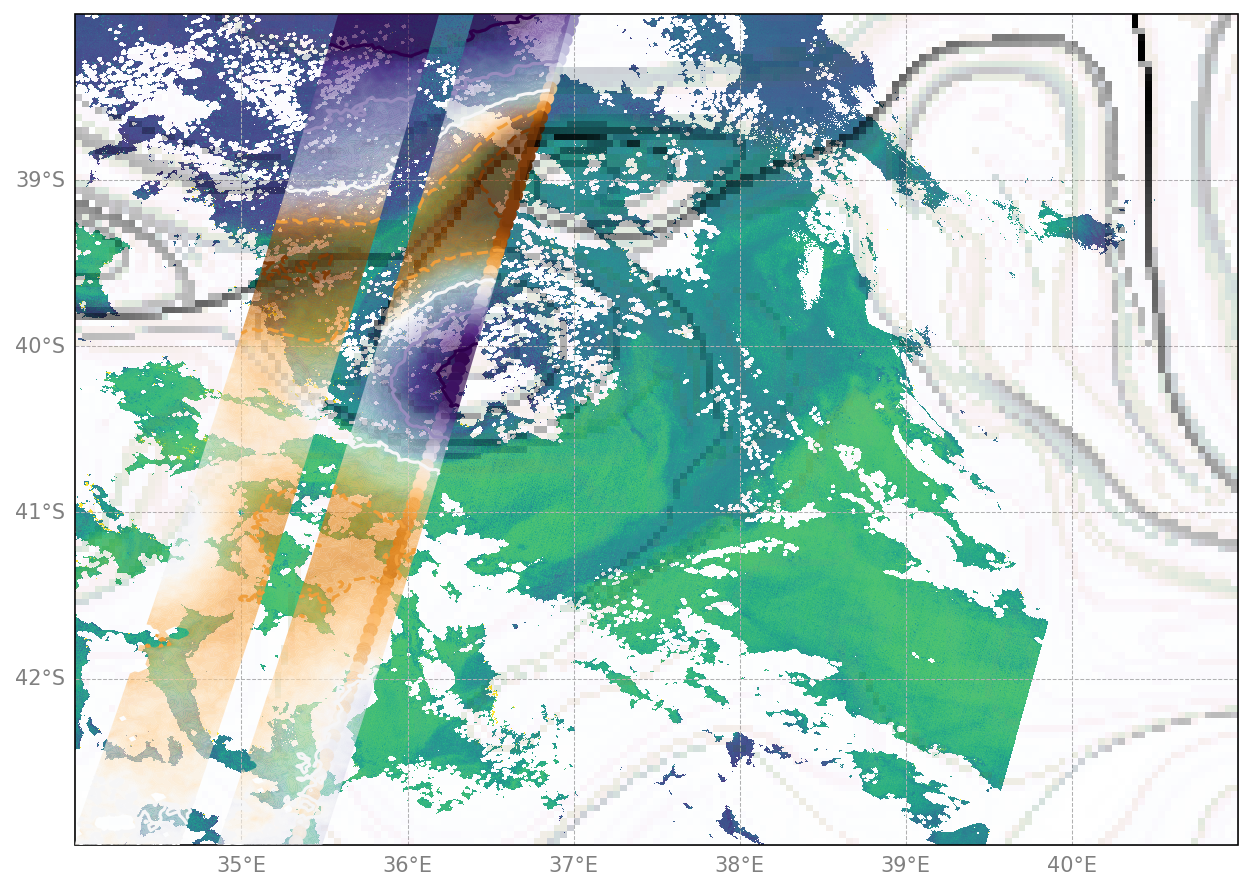

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=150, subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent(ROI["region"], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, linewidth=1, facecolor='lightgrey', edgecolor='k', zorder=0)

chlamap = ax.pcolormesh(lon, lat, chla['CHL_NN']*NN_mask, transform=ccrs.PlateCarree(), cmap=plot_params["chlacmap"], vmin=plot_params["chlamin"], vmax=plot_params["chlamax"], zorder=1)
fslemap = ax.pcolormesh(lon_fsle, lat_fsle, fsle, cmap=plot_params["fslecmap"], vmin=plot_params["fslemin"], vmax=plot_params["fslemax"], alpha=alphas, zorder=3)
# antialiased=True to avoid contour lines (which appear with an alpha=1... not 0.5, so are visible, with a high number of levels)
swath = ax.contourf(lonswot, latswot, dataswot, levels=levels, cmap=plot_params["sshacmap"], antialiased=True, vmin=plot_params["sshamin"], vmax=plot_params["sshamax"], alpha=0.66, transform=ccrs.PlateCarree(central_longitude=0), zorder=4, extend='both')
swathcont = ax.contour(lonswot, latswot, dataswot, cmap=plot_params["sshacmap"], levels=levels_cont, linestyles=np.where(levels_cont >= 0, "-", "--"), linewidth=0.1, alpha=1, transform=ccrs.PlateCarree(), zorder=5, extend='both')
track = ax.scatter(lonnadir, latnadir, c=sshanadir, cmap=plot_params["sshacmap"], vmin=plot_params["sshamin"], vmax=plot_params["sshamax"], marker='o', edgecolors=None, linewidth=1, alpha=1, transform=ccrs.PlateCarree(central_longitude=0), zorder=1)

# add some map embellishments
embellish_plot(ax)

plt.savefig(os.path.join(output_dir, 'test_alti_ChlA_'+date_tag+'_'+ROI["name"]+'.png'), bbox_inches='tight', transparent=True)
plt.show()
plt.close()

Here also the structures match well - the core of the warm eddies has lower ChlA, as expected, the "comma-like" structure is also there and matches the FSLEs, contours of the visible structures match, also.

<hr>
<a href="../../../Index.ipynb"><< Index</a>
<br>
<hr>
<a href="https://gitlab.eumetsat.int/eumetlab/oceans/ocean-training/applications/ocean-case-studies">View on GitLab</a> | <a href="https://training.eumetsat.int/">EUMETSAT Training</a> | <a href=mailto:ops@eumetsat.int>Contact helpdesk for support </a> | <a href=mailto:.training@eumetsat.int>Contact our training team to collaborate on and reuse this material</a></span></p>